<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

## **Faye**

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Stock Price Prediction - CatBoost**

---

In [1]:
import sys
!{sys.executable} -m pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
    --------------------------------------- 1.3/100.2 MB 16.6 MB/s eta 0:00:06
   -- ------------------------------------- 7.1/100.2 MB 24.2 MB/s eta 0:00:04
   ----- ---------------------------------- 14.7/100.2 MB 28.8 MB/s eta 0:00:03
   -------- ------------------------------- 20.4/100.2 MB 29.3 MB/s eta 0:00:03
   ---------- ----------------------------- 26.5/100.2 MB 29.4 MB/s eta 0:00:03
   ------------- -------------------------- 33.3/100.2 MB 30.6 MB/s eta 0:00:03
   ---------------- ----------------------- 40.4/100.2 MB 30.2 MB/s eta 0:00:02
   ------------------- -------------------- 47.7/100.2 MB 31.0 MB/s eta 0:00:02
   --------------------- ------------------ 54.8/100.2 MB 31.2 MB/s eta 0:00:02
   ------------------------- -------------- 62.7/100.2 MB 31.9 MB/s eta 0:00:02
   --------------------------- ------------ 68.4/100.2 MB 31.8 MB/s eta 0:00:01
   ------------------------------ --------- 75.5/10

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os
import json
import pandas as pd
import numpy as np

In [3]:
msft = yf.Ticker("MSFT")
msft_hist = msft.history(period = "max")

In [4]:
msft_hist

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-03-13 00:00:00-05:00,0.053847,0.061765,0.053847,0.059125,1031788800,0.0,0.0
1986-03-14 00:00:00-05:00,0.059125,0.062293,0.059125,0.061237,308160000,0.0,0.0
1986-03-17 00:00:00-05:00,0.061237,0.062821,0.061237,0.062293,133171200,0.0,0.0
1986-03-18 00:00:00-05:00,0.062293,0.062821,0.060181,0.060709,67766400,0.0,0.0
1986-03-19 00:00:00-05:00,0.060709,0.061237,0.059125,0.059653,47894400,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-16 00:00:00-04:00,395.790009,396.839996,390.690002,393.829987,31506800,0.0,0.0
2026-06-17 00:00:00-04:00,390.250000,390.369995,377.320007,378.910004,41987800,0.0,0.0
2026-06-18 00:00:00-04:00,377.820007,381.369995,373.279999,379.399994,59714200,0.0,0.0


In [5]:
msft_hist.head(5)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-03-13 00:00:00-05:00,0.053847,0.061765,0.053847,0.059125,1031788800,0.0,0.0
1986-03-14 00:00:00-05:00,0.059125,0.062293,0.059125,0.061237,308160000,0.0,0.0
1986-03-17 00:00:00-05:00,0.061237,0.062821,0.061237,0.062293,133171200,0.0,0.0
1986-03-18 00:00:00-05:00,0.062293,0.062821,0.060181,0.060709,67766400,0.0,0.0
1986-03-19 00:00:00-05:00,0.060709,0.061237,0.059125,0.059653,47894400,0.0,0.0


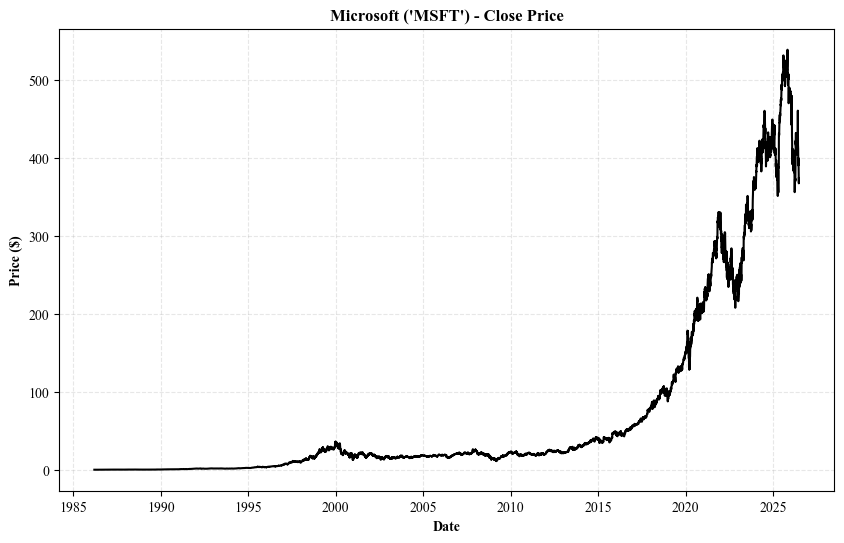

In [6]:
rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (10, 6))

ax.plot(msft_hist.index, msft_hist['Close'], color = 'black', linewidth = 1.5)
ax.set_title("Microsoft ('MSFT') - Close Price", fontweight = 'bold', fontsize = 12)
ax.set_xlabel("Date", fontweight = 'bold')
ax.set_ylabel("Price ($)", fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [7]:
data = msft_hist[["Close"]]
data = data.rename(columns = {'Close': 'Actual Close'})
data["Target"] = msft_hist.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]

In [8]:
data.head(5)

,Actual Close,Target
Date,,
1986-03-13 00:00:00-05:00,0.059125,NaN
1986-03-14 00:00:00-05:00,0.061237,1.0
1986-03-17 00:00:00-05:00,0.062293,1.0
1986-03-18 00:00:00-05:00,0.060709,0.0
1986-03-19 00:00:00-05:00,0.059653,0.0


In [9]:
msft_prev = msft_hist.copy()
msft_prev = msft_prev.shift(1)
msft_prev.head(5)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-03-13 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986-03-14 00:00:00-05:00,0.053847,0.061765,0.053847,0.059125,1.031789e+09,0.0,0.0
1986-03-17 00:00:00-05:00,0.059125,0.062293,0.059125,0.061237,3.081600e+08,0.0,0.0
1986-03-18 00:00:00-05:00,0.061237,0.062821,0.061237,0.062293,1.331712e+08,0.0,0.0
1986-03-19 00:00:00-05:00,0.062293,0.062821,0.060181,0.060709,6.776640e+07,0.0,0.0


In [10]:
predictors = ["Close", "High", "Low", "Open", "Volume"]
data = data.join(msft_prev[predictors]).iloc[1:]
data.head(5)

,Actual Close,Target,Close,High,Low,Open,Volume
Date,,,,,,,
1986-03-14 00:00:00-05:00,0.061237,1.0,0.059125,0.061765,0.053847,0.053847,1.031789e+09
1986-03-17 00:00:00-05:00,0.062293,1.0,0.061237,0.062293,0.059125,0.059125,3.081600e+08
1986-03-18 00:00:00-05:00,0.060709,0.0,0.062293,0.062821,0.061237,0.061237,1.331712e+08
1986-03-19 00:00:00-05:00,0.059653,0.0,0.060709,0.062821,0.060181,0.062293,6.776640e+07
1986-03-20 00:00:00-05:00,0.058070,0.0,0.059653,0.061237,0.059125,0.060709,4.789440e+07


In [11]:
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler

In [12]:
cb_model = CatBoostClassifier(random_state = 1, verbose = 0)

In [13]:
train_data = data.iloc[:-100]
test_data = data.iloc[-100:]

In [14]:
cb_base_scaler = StandardScaler()
X_train_scaled = cb_base_scaler.fit_transform(train_data[predictors])
X_test_scaled = cb_base_scaler.transform(test_data[predictors])

In [15]:
cb_model.fit(X_train_scaled, train_data["Target"])

CatBoostClassifier(random_state=1, verbose=0)

In [16]:
from sklearn.metrics import precision_score

In [17]:
predictions = cb_model.predict(X_test_scaled)
predictions

array([1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
       1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

In [18]:
predictions = pd.Series(predictions, index = test_data.index)
predictions

Date
2026-01-29 00:00:00-05:00    1.0
2026-01-30 00:00:00-05:00    0.0
2026-02-02 00:00:00-05:00    0.0
2026-02-03 00:00:00-05:00    1.0
2026-02-04 00:00:00-05:00    1.0
                            ... 
2026-06-16 00:00:00-04:00    1.0
2026-06-17 00:00:00-04:00    1.0
2026-06-18 00:00:00-04:00    1.0
2026-06-22 00:00:00-04:00    1.0
2026-06-23 00:00:00-04:00    1.0
Length: 100, dtype: float64

In [19]:
precision_score = precision_score(test_data["Target"], predictions)
print(precision_score)

0.45454545454545453


In [20]:
combined_data = pd.concat({"Target": test_data["Target"], "Predictions": predictions}, axis = 1)
combined_data

,Target,Predictions
Date,,
2026-01-29 00:00:00-05:00,0.0,1.0
2026-01-30 00:00:00-05:00,0.0,0.0
2026-02-02 00:00:00-05:00,0.0,0.0
2026-02-03 00:00:00-05:00,0.0,1.0
2026-02-04 00:00:00-05:00,1.0,1.0
...,...,...
2026-06-16 00:00:00-04:00,0.0,1.0
2026-06-17 00:00:00-04:00,0.0,1.0
2026-06-18 00:00:00-04:00,1.0,1.0


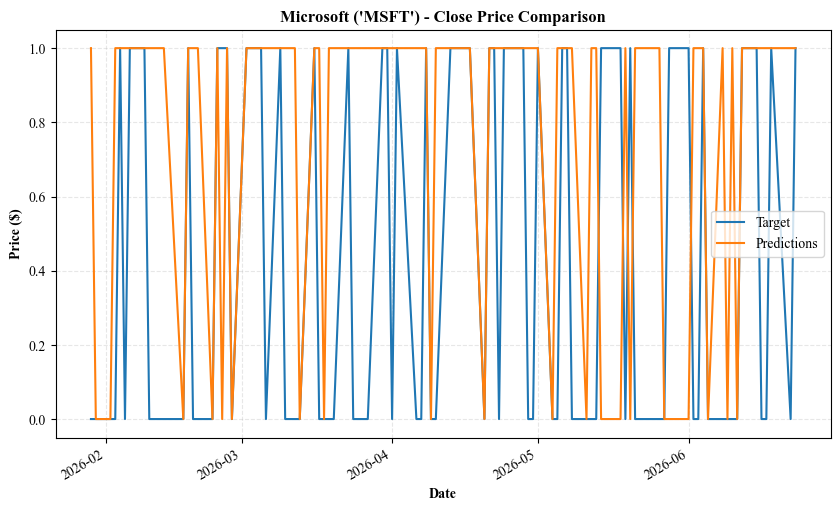

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

combined_data.plot(ax = ax, linewidth = 1.5)
ax.set_title("Microsoft ('MSFT') - Close Price Comparison", fontweight = 'bold', fontsize = 12)
ax.set_xlabel("Date", fontweight = 'bold')
ax.set_ylabel("Price ($)", fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)
ax.legend(title = None)

plt.show()

In [22]:
def backtest(data, model, predictors, start = 1000, step = 750, threshold = 0.5):
    
    all_predictions = []
    
    for i in range(start, data.shape[0], step):
        
        train_data = data.iloc[: i].copy()
        test_data = data.iloc[i : i + step].copy()
        
        loop_scaler = StandardScaler()
        X_train_scaled = loop_scaler.fit_transform(train_data[predictors])
        X_test_scaled = loop_scaler.transform(test_data[predictors])
        
        model.fit(X_train_scaled, train_data["Target"])
        
        predictions = model.predict_proba(X_test_scaled)[:, 1]
        predictions = pd.Series(predictions, index = test_data.index)
        predictions[predictions > threshold] = 1
        predictions[predictions <= threshold] = 0
        
        combined_data = pd.concat({"Target": test_data["Target"], "Predictions": predictions}, axis = 1)

        all_predictions.append(combined_data)

    return pd.concat(all_predictions)

In [23]:
predictions = backtest(data, cb_model, predictors, threshold = 0.6)

In [24]:
predictions["Predictions"].value_counts()

Predictions
0.0    7587
1.0    1559
Name: count, dtype: int64

In [25]:
from sklearn.metrics import precision_score

precision_score_2 = precision_score(predictions["Target"], predictions["Predictions"])
print(precision_score_2)

0.517639512508018


In [26]:
weekly_mean = data.rolling(7).mean()
quarterly_mean = data.rolling(90).mean()
annual_mean = data.rolling(365).mean()
weekly_trend = data.shift(1).rolling(7).mean()["Target"]

In [27]:
data["weekly_mean"] = weekly_mean["Close"] / data["Close"]
data["quarterly_mean"] = quarterly_mean["Close"] / data["Close"]
data["annual_mean"] = annual_mean["Close"] / data["Close"]

data["annual_weekly_mean"] = data["annual_mean"] / data["weekly_mean"]
data["annual_quarterly_mean"] = data["annual_mean"] / data["quarterly_mean"]
data["weekly_trend"] = weekly_trend

data["open_close_ratio"] = data["Open"] / data["Close"]
data["high_close_ratio"] = data["High"] / data["Close"]
data["low_close_ratio"] = data["Low"] / data["Close"]

In [28]:
full_predictors = predictors + ["weekly_mean", 
                                "quarterly_mean", 
                                "annual_mean", 
                                "annual_weekly_mean", 
                                "annual_quarterly_mean", 
                                "open_close_ratio", 
                                "high_close_ratio", 
                                "low_close_ratio", 
                                "weekly_trend"]

In [29]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

tuning_data = data.iloc[365:].dropna().copy()

tuning_scaler = StandardScaler()
X_tuning_scaled = tuning_scaler.fit_transform(tuning_data[full_predictors])
y_tuning = tuning_data["Target"].values

param_dist = {'iterations': [50, 100, 200, 300],            
              'depth': [4, 6, 8, 10],                       
              'learning_rate': [0.01, 0.05, 0.1, 0.2],      
              'l2_leaf_reg': [1, 3, 5, 10],                 
              'border_count': [32, 64, 128, 254],           
              'random_strength': [0.0, 1.0, 2.0]}

tscv = TimeSeriesSplit(n_splits = 5)

random_search = RandomizedSearchCV(estimator = CatBoostClassifier(random_state = 1, verbose = 0),
                                   param_distributions = param_dist,
                                   n_iter = 15, 
                                   scoring = 'precision', 
                                   cv = tscv,
                                   n_jobs = -1,
                                   random_state = 1)

random_search.fit(X_tuning_scaled, y_tuning)

best_cb_model = random_search.best_estimator_
print("Best parameters found:", random_search.best_params_)

Best parameters found: {'random_strength': 2.0, 'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 100, 'depth': 8, 'border_count': 64}


In [30]:
predictions = backtest(data.iloc[365:], best_cb_model, full_predictors, threshold = 0.6)

In [31]:
from sklearn.metrics import precision_score

precision_score_3 = precision_score(predictions["Target"], predictions["Predictions"])
print(precision_score_3)

0.46153846153846156


In [32]:
predictions["Predictions"].value_counts()

Predictions
0.0    8768
1.0      13
Name: count, dtype: int64

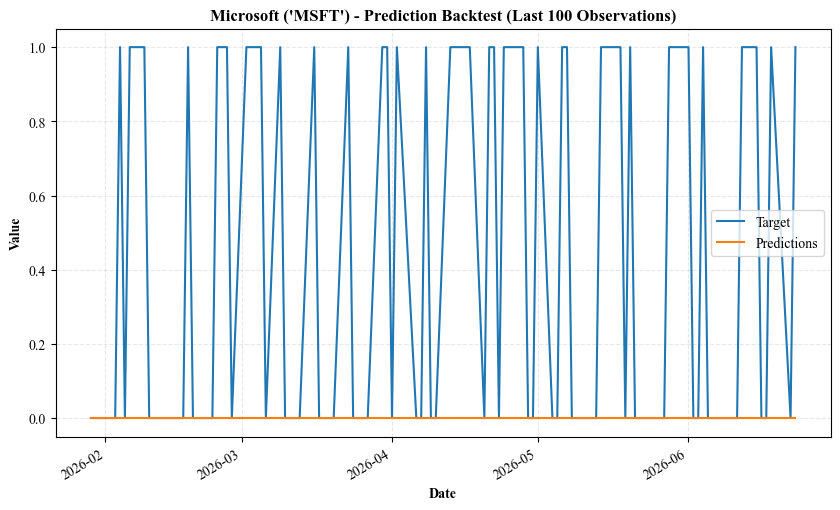

In [33]:
fig, ax = plt.subplots(figsize = (10, 6))

predictions.iloc[-100:].plot(ax = ax, linewidth = 1.5)
ax.set_title("Microsoft ('MSFT') - Prediction Backtest (Last 100 Observations)", fontweight = 'bold', fontsize = 12)
ax.set_xlabel("Date", fontweight = 'bold')
ax.set_ylabel("Value", fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)
ax.legend(title = None, loc = 'center right')

plt.show()